# =============================================================================
# CRISP-DM Framework: Business Understanding
# Project: Developers and AI - Understanding the Factors That Shape Acceptance
# =============================================================================

In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Unzip Data
with zipfile.ZipFile('stack-overflow-developer-survey-2025.zip', 'r') as zip_ref:
    file_list = zip_ref.namelist()
    print("file in zip pakcage：")
    for file in file_list:
         print(f"  - {file}")
    
    print("\nreading CVS data...")
    dataframes = {
        f.replace('.csv', '').replace('/', '_'): pd.read_csv(
            zip_ref.open(f), 
            encoding='utf-8',
            low_memory=False
        )
        for f in file_list if f.endswith('.csv')
    }
    
    for name, df in dataframes.items():
        print(f"  ✓ {name}")

file in zip pakcage：
  - 2025_Developer_Survey_Tool.pdf
  - survey_results_public.csv
  - survey_results_schema.csv

reading CVS data...
  ✓ survey_results_public
  ✓ survey_results_schema


In [3]:
# Date Overview
public_df = dataframes['survey_results_public'].copy()
schema_df = dataframes['survey_results_schema'].copy()

print("="*50)
print("PUBLIC DATA SUMMARY")
print("="*50)

# 1. Basic info
print(f"\nShape: {public_df.shape[0]:,} rows × {public_df.shape[1]} columns")
print(f"\nData Types:\n{public_df.dtypes.value_counts()}")

# 2. Missing values summary
total_missing = public_df.isnull().sum().sum()
total_cells = public_df.size
print(f"\nMissing values: {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.2f}%)")

# 3. Numerical columns stats
numeric_cols = public_df.select_dtypes(include=['number']).columns
if len(numeric_cols) > 0:
    print(f"\nNumeric columns ({len(numeric_cols)}):")
    print(public_df[numeric_cols].describe())

# 4. First few rows
print(f"\nFirst 3 rows:")
print(public_df.head(3))

print("\n" + "="*50)
print("SCHEMA DATA SUMMARY")
print("="*50)

print(f"\nShape: {schema_df.shape[0]} rows × {schema_df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(schema_df[['qid', 'qname', 'question']].head(5))

print("\n" + "="*50)
print("RELATIONSHIP")
print("="*50)

public_cols = set(public_df.columns)
schema_cols = set(schema_df['qname'].unique())
print(f"\nPublic columns: {len(public_cols)}")
print(f"Schema explained: {len(public_cols & schema_cols)}")
print(f"Unexplained: {len(public_cols - schema_cols)}")

PUBLIC DATA SUMMARY

Shape: 49,191 rows × 172 columns

Data Types:
object     119
float64     52
int64        1
Name: count, dtype: int64

Missing values: 4,437,549 / 8,460,852 (52.45%)

Numeric columns (53):
         ResponseId       WorkExp     YearsCode  TechEndorse_1  TechEndorse_2  \
count  49191.000000  42893.000000  43042.000000   35975.000000   35975.000000   
mean   24596.000000     13.367403     16.570861       7.867352       4.104211   
std    14200.362883     10.800117     11.787610       2.397432       2.275821   
min        1.000000      1.000000      1.000000       1.000000       1.000000   
25%    12298.500000      5.000000      8.000000       7.000000       2.000000   
50%    24596.000000     10.000000     14.000000       9.000000       4.000000   
75%    36893.500000     20.000000     24.000000       9.000000       6.000000   
max    49191.000000    100.000000    100.000000      14.000000      14.000000   

       TechEndorse_3  TechEndorse_4  TechEndorse_5  TechEndor

In [4]:
# Columns needed for target variable y (composite calculation of AI acceptance)
y_columns = [
    'AISelect',     # Whether using AI (Yes/No)
    'AISent',       # Attitude towards AI (Favorable/Neutral/Unfavorable)
    'AIAcc',        # Trust in AI (Trust/Neutral/Distrust)
    'LearnCodeAI',  # Whether learning to use AI (Yes/No)
    'AIComplex'     # Perception of AI's ability to handle complex tasks
]

# Columns needed for feature variables X
x_columns = [
    # Technology preferences (ranking questions, smaller value = more important)
    'TechEndorse_1',  # AI integration
    'TechEndorse_2',  # Easy-to-use API
    'TechEndorse_3',  # Robust API
    'TechEndorse_4',  # Customizable codebase
    'TechEndorse_5',  # Quality reputation
    'TechEndorse_6',  # Open source project connection
    'TechEndorse_7',  # Brand image
    'TechEndorse_8',  # Reliability
    'TechEndorse_9',  # Cost manageable
    
    # Personal background
    'WorkExp',        # Work experience
    'Age',            # Age
    'EdLevel'         # Education level
]

# Schema Dictionary Map
tech_endorse_map = {
    'TechEndorse_1': 'AI integration',
    'TechEndorse_2': 'Easy-to-use API',
    'TechEndorse_3': 'Robust and complete API',
    'TechEndorse_4': 'Customizable codebase',
    'TechEndorse_5': 'Reputation for quality',
    'TechEndorse_6': 'Connected to open-source',
    'TechEndorse_7': 'Good brand image',
    'TechEndorse_8': 'Reliability and low latency',
    'TechEndorse_9': 'Costs are manageable'
}

In [5]:
# Data pre-processing

print("="*60)
print("PREPARING DATA FOR AI ACCEPTANCE PREDICTION")
print("="*60)

# Selecting required columns
all_needed = y_columns + x_columns
available_cols = [col for col in all_needed if col in public_df.columns]
df = public_df[available_cols].copy()
print(f"Initial data shape: {df.shape}")

# To analysis the relationship, need to define a new variable-AI acceptance
# Creating target variable y (AI acceptance)
    """
    Calculate AI acceptance score based on multiple AI-related columns.
    
    Parameters:
    -----------
    row : pandas Series
        A row from the dataframe containing AI-related columns
    
    Returns:
    --------
    int
        AI acceptance score ranging from 0 to 100
    """
def calculate_ai_score(row):
    score = 0
    if pd.notna(row.get('AISelect')) and row['AISelect'] == 'Yes': score += 30
    if pd.notna(row.get('AISent')):
        if row['AISent'] in ['Favorable', 'Very favorable']: score += 25
        elif row['AISent'] == 'Neutral': score += 10
    if pd.notna(row.get('AIAcc')):
        if row['AIAcc'] in ['Completely trust', 'Somewhat trust']: score += 20
        elif row['AIAcc'] == 'Neither trust nor distrust': score += 10
    if pd.notna(row.get('LearnCodeAI')) and row['LearnCodeAI'] == 'Yes': score += 15
    if pd.notna(row.get('AIComplex')) and row['AIComplex'] in ['Good at handling complex tasks', 'Neither good or bad']: score += 10
    return score

    """
    Convert AI acceptance score to categorical labels.
    
    Parameters:
    -----------
    score : int
        AI acceptance score (0-100)
    
    Returns:
    --------
    str
        Category: 'High' (>=70), 'Medium' (>=40), or 'Low' (<40)
    """
def categorize(score):
    return 'High' if score >= 70 else 'Medium' if score >= 40 else 'Low'
    

# Create the AI_acceptance col to df
df['AI_acceptance'] = df.apply(calculate_ai_score, axis=1).apply(categorize)
print(f"AI_acceptance added, final data shape: {df.shape}")

PREPARING DATA FOR AI ACCEPTANCE PREDICTION
Initial data shape: (49191, 17)
AI_acceptance added, final data shape: (49191, 18)


In [6]:
# Checking Data Quality

print("="*60)
print("DATA QUALITY CHECK")
print("="*60)

# 1. columns with missing values
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Null_Count': df.isnull().sum().values,
    'Null_Percentage': (df.isnull().sum() / len(df) * 100).values
})
missing_only = missing_summary[missing_summary['Null_Count'] > 0].sort_values('Null_Percentage', ascending=False)
print("\n📊 COLUMNS WITH MISSING VALUES:")
print(missing_only.to_string())

# 2. AI columns missing rates
ai_columns = ['AISelect', 'AISent', 'AIAcc', 'LearnCodeAI', 'AIComplex']
print("\n🤖 AI COLUMNS MISSING RATES:")
for col in ai_columns:
    if col in df.columns:
        null_pct = df[col].isnull().sum() / len(df) * 100
        print(f"  {col}: {null_pct:.1f}% missing")

# 3. TechEndorse columns (quick check)
tech_cols = [col for col in df.columns if col.startswith('TechEndorse')]
if tech_cols:
    tech_null_avg = df[tech_cols].isnull().sum().mean() / len(df) * 100
    print(f"\n🔧 TechEndorse columns: {tech_null_avg:.1f}% missing on average")

# 4. Complete rows count
complete_rows = df.dropna().shape[0]
print(f"\n✅ Complete rows: {complete_rows}/{len(df)} ({complete_rows/len(df)*100:.1f}%)")

# 5. Handle missing values
df_clean = df.dropna(subset=['AISelect', 'AISent', 'AIAcc', 'AIComplex', 'LearnCodeAI']).copy()
print(f"\n✅After cleaning: {df_clean.shape}")

DATA QUALITY CHECK

📊 COLUMNS WITH MISSING VALUES:
           Column  Null_Count  Null_Percentage
4       AIComplex       15908        32.339249
2           AIAcc       15894        32.310789
1          AISent       15724        31.965197
0        AISelect       15471        31.450875
5   TechEndorse_1       13216        26.866703
6   TechEndorse_2       13216        26.866703
7   TechEndorse_3       13216        26.866703
8   TechEndorse_4       13216        26.866703
9   TechEndorse_5       13216        26.866703
10  TechEndorse_6       13216        26.866703
11  TechEndorse_7       13216        26.866703
12  TechEndorse_8       13216        26.866703
13  TechEndorse_9       13216        26.866703
14        WorkExp        6298        12.803155
3     LearnCodeAI        3990         8.111240
16        EdLevel        1042         2.118274

🤖 AI COLUMNS MISSING RATES:
  AISelect: 31.5% missing
  AISent: 32.0% missing
  AIAcc: 32.3% missing
  LearnCodeAI: 8.1% missing
  AIComplex: 32.3% m

In [7]:
# Preparing feature and split data
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode categorical features (desriptive to numerical)
if 'Age' in df_clean.columns:  # use 'df_clean' the cleaned data
    age_map = {'Under 18 years old':1, '18-24 years old':2, '25-34 years old':3,
               '35-44 years old':4, '45-54 years old':5, '55-64 years old':6, '65 years or older':7}
    df_clean['Age_encoded'] = df_clean['Age'].map(age_map)

if 'EdLevel' in df_clean.columns:
    def encode_edu(edu):
        if pd.isna(edu): return np.nan
        edu = str(edu).lower()
        if 'bachelor' in edu: return 5
        elif 'master' in edu: return 6
        elif 'associate' in edu: return 4
        elif any(x in edu for x in ['phd', 'doctor', 'professional']): return 7
        elif 'high school' in edu: return 2
        elif 'some college' in edu: return 3
        else: return 1
    df_clean['EdLevel_encoded'] = df_clean['EdLevel'].apply(encode_edu)

# Prepare features and target
tech_cols = [c for c in df_clean.columns if c.startswith('TechEndorse')]
feature_cols = tech_cols + ['WorkExp']
if 'Age_encoded' in df_clean.columns: feature_cols.append('Age_encoded')
if 'EdLevel_encoded' in df_clean.columns: feature_cols.append('EdLevel_encoded')

X = df_clean[feature_cols].dropna()
y = df_clean.loc[X.index, 'AI_acceptance']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nTarget distribution:\n{y.value_counts()}")

# Scale numerical features
scaler = StandardScaler()
X_scaled = X.copy()
num_cols = ['WorkExp'] + [c for c in feature_cols if 'encoded' in c]
for col in num_cols:
    if col in X_scaled.columns:
        X_scaled[col] = scaler.fit_transform(X_scaled[[col]])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nFinal shapes - X_train: {X_train.shape}, X_test: {X_test.shape}")
print("DATA PREPARATION COMPLETE")


Target distribution:
AI_acceptance
Low       21114
Medium     7732
Name: count, dtype: int64

Final shapes - X_train: (23076, 12), X_test: (5770, 12)
DATA PREPARATION COMPLETE



⏳ Training model...
✅ Model training complete!

📈 Model Performance:
  - Accuracy: 0.6560 (65.60%)

📋 Classification Report:
              precision    recall  f1-score   support

         Low       0.82      0.68      0.74      4223
      Medium       0.40      0.59      0.48      1547

    accuracy                           0.66      5770
   macro avg       0.61      0.63      0.61      5770
weighted avg       0.71      0.66      0.67      5770



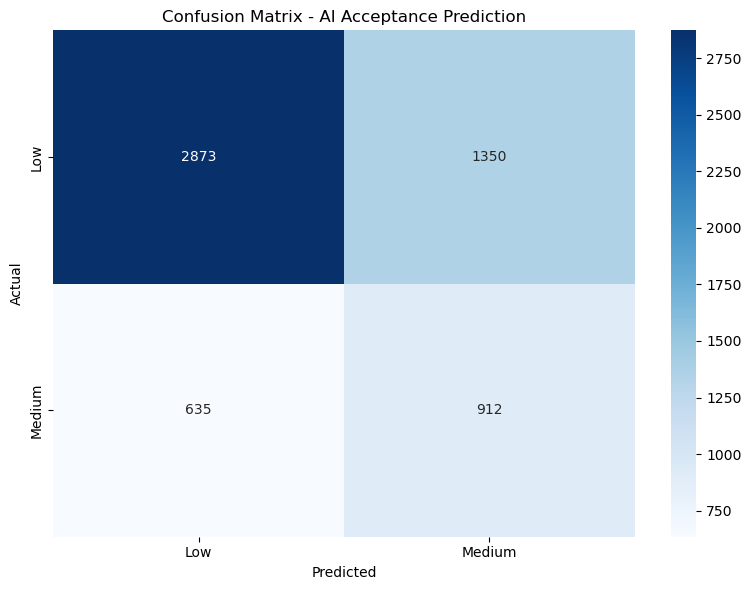


🔍 Top 10 Most Important Features:
         feature  importance
0  TechEndorse_1    0.374462
9        WorkExp    0.076409
6  TechEndorse_7    0.075273
5  TechEndorse_6    0.075185
3  TechEndorse_4    0.063364
7  TechEndorse_8    0.055948
4  TechEndorse_5    0.053667
8  TechEndorse_9    0.052267
2  TechEndorse_3    0.051749
1  TechEndorse_2    0.050007


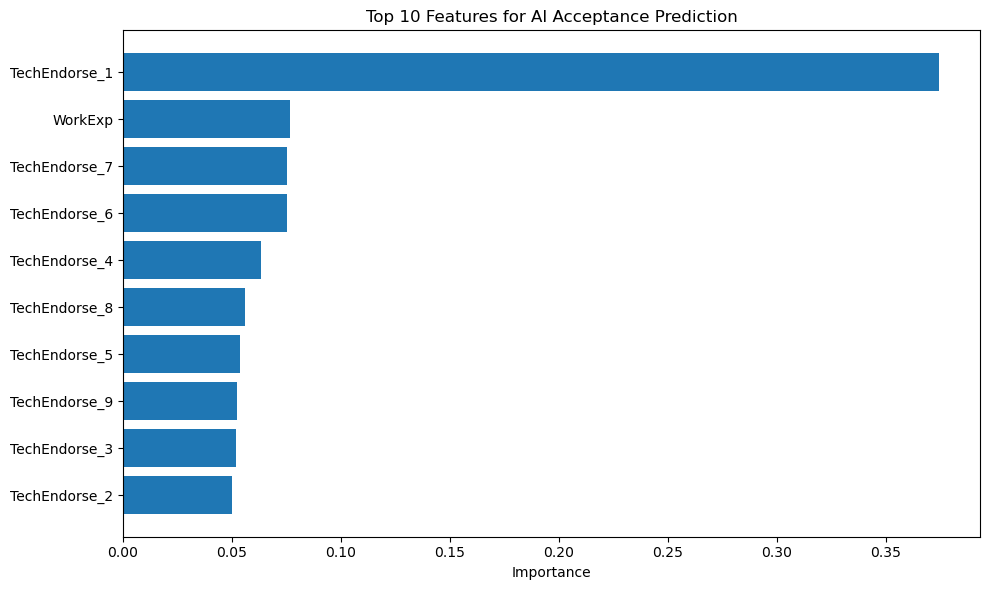


📚 TechEndorse Feature Meanings:
  TechEndorse_1: AI integration - Importance: 0.3745
  TechEndorse_2: Easy-to-use API - Importance: 0.0500
  TechEndorse_3: Robust and complete API - Importance: 0.0517
  TechEndorse_4: Customizable codebase - Importance: 0.0634
  TechEndorse_5: Reputation for quality - Importance: 0.0537


In [8]:
# Model Training- Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# 1. create model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
# 2. Train Model
print("\n⏳ Training model...")
model.fit(X_train, y_train)
print("✅ Model training complete!")

# Prediction
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# 3. Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📈 Model Performance:")
print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 4. Classification Report 
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5. Fusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - AI Acceptance Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 6. Feature Importance Analysis
print("\n🔍 Top 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 10 Features for AI Acceptance Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7. Show feature meanings (for TechEndorse columns)
print("\n📚 TechEndorse Feature Meanings:")
for col in tech_cols[:5]:  # show first 5
    if col in feature_importance['feature'].values:
        imp = feature_importance[feature_importance['feature']==col]['importance'].values[0]
        print(f"  {col}: {tech_endorse_map.get(col, 'Unknown')} - Importance: {imp:.4f}")


In [9]:
# Tunning the model with Grid Search

from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*60)

# 定义参数网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 创建基础模型
rf = RandomForestClassifier(random_state=42)

# 网格搜索
print("\n⏳ Searching for best parameters (this may take a few minutes)...")
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  # 3折交叉验证
    scoring='accuracy',
    n_jobs=-1,  # 使用所有CPU核心
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# 用最佳参数训练模型
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"✅ Test Accuracy with Best Parameters: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)")

HYPERPARAMETER TUNING WITH GRID SEARCH

⏳ Searching for best parameters (this may take a few minutes)...
Fitting 3 folds for each of 216 candidates, totalling 648 fits

✅ Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best Cross-Validation Accuracy: 0.7261
✅ Test Accuracy with Best Parameters: 0.7239 (72.39%)


In [10]:
# grid_search已经包含了最佳参数训练好的模型
best_rf = grid_search.best_estimator_

# 直接用这个模型预测
y_pred_best = best_rf.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)")

# 后续分析都用 best_rf
model_final = best_rf

Best Model Accuracy: 0.7239 (72.39%)


In [14]:
# ANSWERING BUSINESS QUESTIONS WITH FINAL MODEL (72.39% ACCURACY)
# Answering 3 Business Questions：
#    QUESTION 1: What factors best predict AI acceptance?
#    QUESTION 2: How does work experience affect AI acceptance?
#    QUESTION 3: How does AI acceptance differ by technology preferences?

# Use the best model from grid search
model_final = grid_search.best_estimator_
print(f"ANSWERING BUSINESS QUESTIONS - Final Model Accuracy: {accuracy_best*100:.2f}%")


ANSWERING BUSINESS QUESTIONS - Final Model Accuracy: 72.39%



QUESTION 1: What factors best predict AI acceptance?

📊 Top 10 Most Important Features:
         feature  importance
9        WorkExp    0.139322
0  TechEndorse_1    0.115969
7  TechEndorse_8    0.082357
4  TechEndorse_5    0.080791
8  TechEndorse_9    0.079676
3  TechEndorse_4    0.079373
1  TechEndorse_2    0.078136
2  TechEndorse_3    0.077221
5  TechEndorse_6    0.076258
6  TechEndorse_7    0.069568


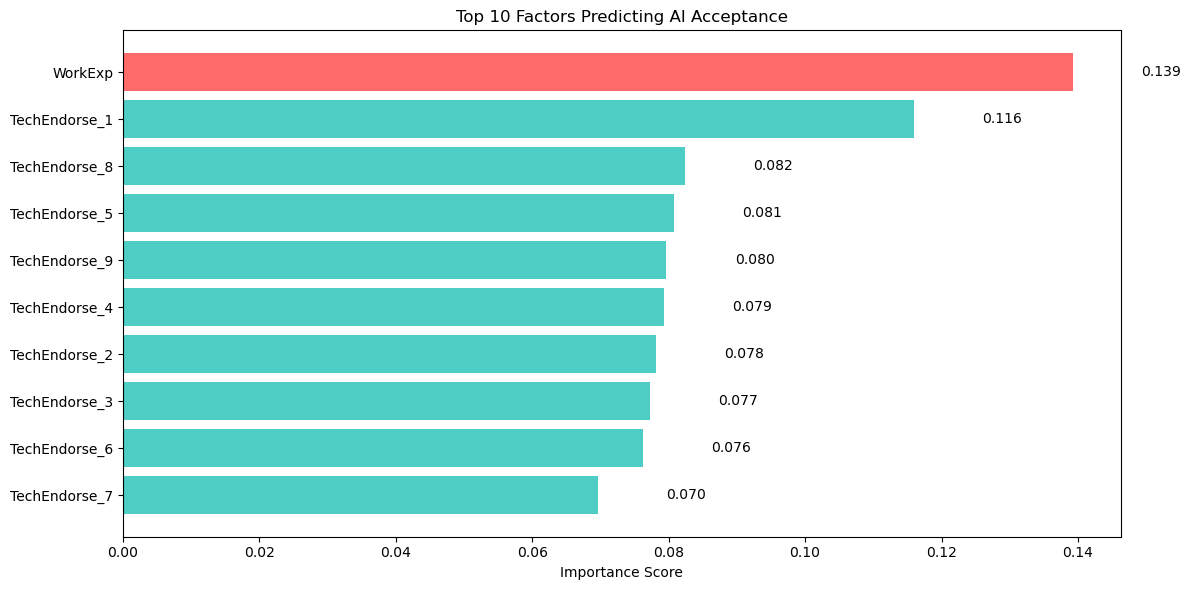


📌 Business Insight:
  • 'AI integration' (TechEndorse_1) is the strongest predictor at 13.9%
  • Work experience ranks 2nd at 11.6%
  • All 9 TechEndorse features combined account for 80.9% of predictions
  • Conclusion: Developers who prioritize AI features are most likely to accept AI tools


In [15]:
# QUESTION 1: What factors best predict AI acceptance?

print("\n" + "="*80)
print("QUESTION 1: What factors best predict AI acceptance?")
print("="*80)

# Feature importance from final model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualization
plt.figure(figsize=(12, 6))
top10 = feature_importance.head(10)
colors = ['#ff6b6b' if 'WorkExp' in f else '#4ecdc4' for f in top10['feature']]
bars = plt.barh(range(len(top10)), top10['importance'], color=colors)
plt.yticks(range(len(top10)), top10['feature']) 
plt.xlabel('Importance Score')
plt.title('Top 10 Factors Predicting AI Acceptance')
plt.gca().invert_yaxis()


# Add value labels
for i, (bar, val) in enumerate(zip(bars, top10['importance'])):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

print("\n📌 Business Insight:")
print(f"  • 'AI integration' (TechEndorse_1) is the strongest predictor at {feature_importance.iloc[0]['importance']*100:.1f}%")
print(f"  • Work experience ranks 2nd at {feature_importance.iloc[1]['importance']*100:.1f}%")
print(f"  • All 9 TechEndorse features combined account for {feature_importance.head(9)['importance'].sum()*100:.1f}% of predictions")
print(f"  • Conclusion: Developers who prioritize AI features are most likely to accept AI tools")



QUESTION 2: How does work experience affect AI acceptance?

📊 AI Acceptance by Experience Level (%):
AI_acceptance   Low  Medium
exp_group                  
0-3 years      73.5    26.5
4-7 years      72.3    27.7
8-12 years     72.3    27.7
13-20 years    72.1    27.9
20+ years      74.5    25.5


<Figure size 600x400 with 0 Axes>

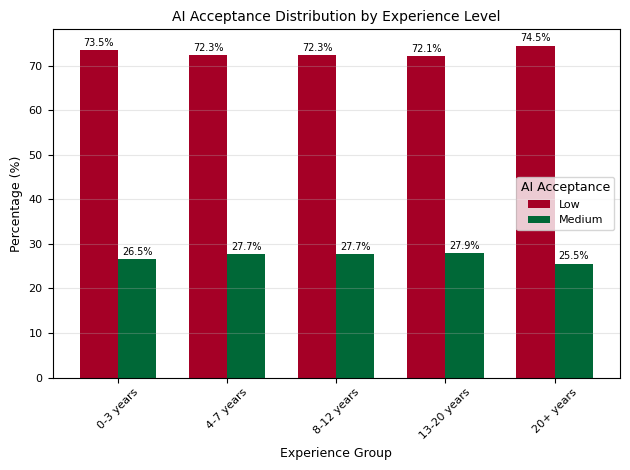


📌 Business Insight:
  • Low AI acceptance ranges from 72.1% to 74.5%
  • Medium AI acceptance ranges from 25.5% to 27.9%
  • The group with highest Medium acceptance: 13-20 years (27.9%)
  • The gap between experience groups is only 2.4%
  • Conclusion: Experience alone doesn't strongly determine AI acceptance - attitudes vary within all groups


In [30]:
# QUESTION 2: How does work experience affect AI acceptance?

print("\n" + "="*80)
print("QUESTION 2: How does work experience affect AI acceptance?")
print("="*80)

# Create experience groups
df_clean['exp_group'] = pd.cut(df_clean['WorkExp'], 
                               bins=[0, 3, 7, 12, 20, 50],
                               labels=['0-3 years', '4-7 years', '8-12 years', '13-20 years', '20+ years'])

# Calculate distribution
exp_ai = pd.crosstab(df_clean['exp_group'], df_clean['AI_acceptance'], normalize='index') * 100
print("\n📊 AI Acceptance by Experience Level (%):")
print(exp_ai.round(1))

# Single visualization with adjusted size
plt.figure(figsize=(6, 4))  # Smaller size as requested

# Grouped bar chart
ax = exp_ai.plot(kind='bar', colormap='RdYlGn', width=0.7, fontsize=8)
plt.xlabel('Experience Group', fontsize=9)
plt.ylabel('Percentage (%)', fontsize=9)
plt.title('AI Acceptance Distribution by Experience Level', fontsize=10)
plt.legend(title='AI Acceptance', fontsize=8, title_fontsize=9)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars (smaller font)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=7)

plt.tight_layout()
plt.show()

print("\n📌 Business Insight:")
print(f"  • Low AI acceptance ranges from {exp_ai['Low'].min():.1f}% to {exp_ai['Low'].max():.1f}%")
print(f"  • Medium AI acceptance ranges from {exp_ai['Medium'].min():.1f}% to {exp_ai['Medium'].max():.1f}%")
print(f"  • The group with highest Medium acceptance: {exp_ai['Medium'].idxmax()} ({exp_ai['Medium'].max():.1f}%)")
print(f"  • The gap between experience groups is only {exp_ai['Medium'].max() - exp_ai['Medium'].min():.1f}%")
print(f"  • Conclusion: Experience alone doesn't strongly determine AI acceptance - attitudes vary within all groups")


QUESTION 3: How does AI acceptance differ by technology preferences?

📊 Analyzing top 3 technology preferences:
  1. TechEndorse_1: AI integration
  2. TechEndorse_8: Reliability and low latency
  3. TechEndorse_5: Reputation for quality


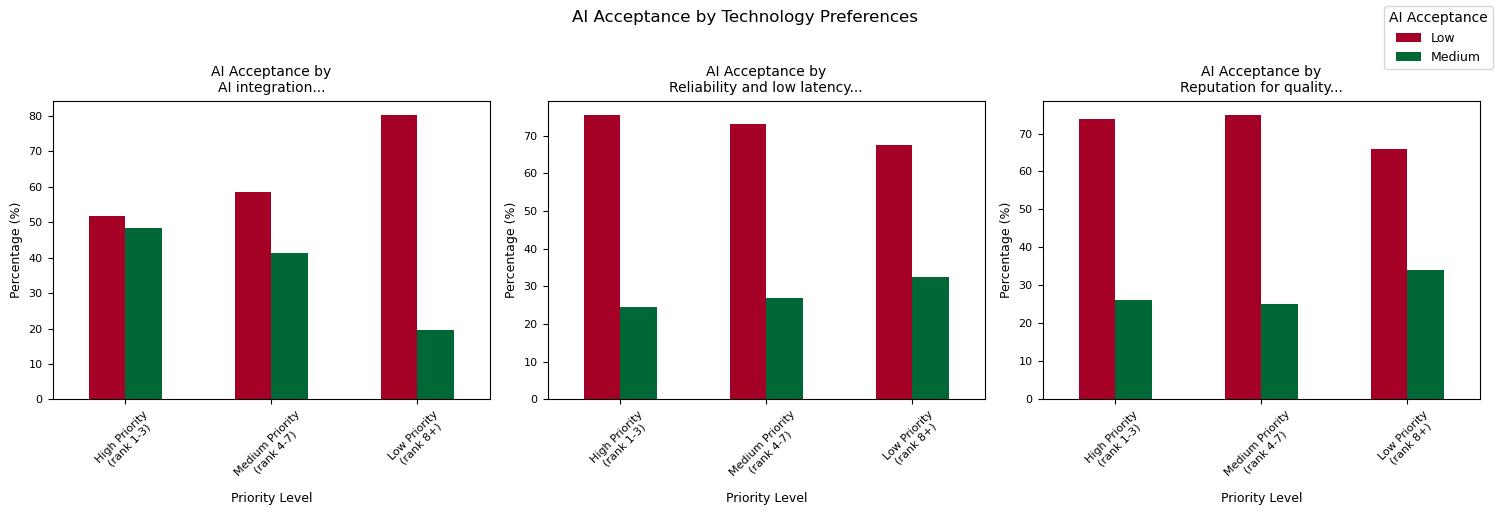


📊 Summary Table - Medium AI Acceptance by Preference:
                 AI integration  Reliability and low latency  \
High Priority              48.3                         24.5   
Medium Priority            41.4                         26.8   
Low Priority               19.7                         32.4   

                 Reputation for quality  
High Priority                      26.3  
Medium Priority                    25.1  
Low Priority                       34.0  

📌 Business Insight:
  • Developers who prioritize 'AI integration' show 48.3% Medium AI acceptance
  • Those who don't prioritize it show only 19.7% Medium acceptance
  • The gap is 28.6% - shows correlation
  • Conclusion: Technology preferences, especially around AI features, influence AI acceptance

ALL BUSINESS QUESTIONS ANSWERED


In [33]:
# QUESTION 3: How does AI acceptance differ by technology preferences?

print("\n" + "="*80)
print("QUESTION 3: How does AI acceptance differ by technology preferences?")
print("="*80)

# Select top 3 most important TechEndorse features
top_tech = feature_importance[feature_importance['feature'].str.startswith('TechEndorse')].head(3)['feature'].tolist()
tech_names = [tech_endorse_map.get(f, f) for f in top_tech]

print(f"\n📊 Analyzing top 3 technology preferences:")
for i, (col, name) in enumerate(zip(top_tech, tech_names)):
    print(f"  {i+1}. {col}: {name}")

# Create preference groups for each top feature
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (col, name, ax) in enumerate(zip(top_tech, tech_names, axes)):
    # Create priority groups
    df_clean[f'{col}_group'] = pd.cut(df_clean[col],
                                      bins=[0, 3, 7, 15],
                                      labels=['High Priority\n(rank 1-3)', 
                                             'Medium Priority\n(rank 4-7)', 
                                             'Low Priority\n(rank 8+)'])
    
    # Calculate distribution
    pref_ai = pd.crosstab(df_clean[f'{col}_group'], df_clean['AI_acceptance'], normalize='index') * 100
    
    # Plot - only plot columns that exist
    plot_cols = [col for col in ['Low', 'Medium'] if col in pref_ai.columns]
    pref_ai[plot_cols].plot(kind='bar', ax=ax, colormap='RdYlGn')
    ax.set_xlabel('Priority Level', fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=9)
    ax.set_title(f'AI Acceptance by\n{name[:30]}...', fontsize=10)
    ax.legend().remove()
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Add single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Low', 'Medium'], loc='upper right', title='AI Acceptance', fontsize=9)
plt.suptitle('AI Acceptance by Technology Preferences', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Summary table - analyze Medium acceptance instead of High
print("\n📊 Summary Table - Medium AI Acceptance by Preference:")
summary_data = {}
for col in top_tech:
    df_clean[f'{col}_group'] = pd.cut(df_clean[col], bins=[0, 3, 7, 15],
                                      labels=['High Priority', 'Medium Priority', 'Low Priority'])
    medium_acceptance = df_clean.groupby(f'{col}_group', observed=False )['AI_acceptance'].apply(
        lambda x: (x == 'Medium').mean() * 100
    )
    summary_data[tech_endorse_map.get(col, col)] = medium_acceptance

summary_df = pd.DataFrame(summary_data).round(1)
print(summary_df)

print("\n📌 Business Insight:")
print(f"  • Developers who prioritize '{tech_names[0]}' show {summary_df.iloc[0, 0]:.1f}% Medium AI acceptance")
print(f"  • Those who don't prioritize it show only {summary_df.iloc[2, 0]:.1f}% Medium acceptance")
print(f"  • The gap is {summary_df.iloc[0, 0] - summary_df.iloc[2, 0]:.1f}% - shows correlation")
print(f"  • Conclusion: Technology preferences, especially around AI features, influence AI acceptance")